# 07 - Hyperparameter Tuning with Forward-Chaining Validation

**Goal:** see how much tuning each model's settings improves the time-aware results, **without ever touching the test batches**.

> **Beginner note - what is a hyperparameter?**
> A *parameter* is something the model learns from data (e.g. the split points of a tree). A *hyperparameter* is a setting **we** choose before
> training (e.g. how many neighbours kNN looks at, or how deep a tree may grow). Until now every model used scikit-learn's defaults.
> **Tuning** means trying many settings and keeping the best one.
>
> **The golden rule.** If we pick settings by looking at the test batches, the test score is no longer an honest estimate - we have
> "peeked at the exam". So settings are chosen on **validation** data taken from *inside the training batches*.
>
> **Why forward chaining?** Our data are chronological, so validation must also look forward in time. With training batches 1-3:
> * fold 1: train on batch 1, validate on batch 2
> * fold 2: train on batches 1 and 2, validate on batch 3
>
> A setting's score is its **mean validation macro-F1** over the two folds. (Ordinary random cross-validation would validate on near-identical
> "twins" of the training samples and always favour settings that merely memorise.)

**Rules of this notebook**
1. Every grid **contains the scikit-learn default**, so tuning can never look worse than the default *on validation*; ties go to the default.
2. Tuning uses **batches 1-3 only**. The tuned models are then tested on **batches 4-10** (protocol P1), which no tuning step has seen.
3. For the rolling protocol P3 we reuse the same settings but report only test batches 4-10 (batches 2-3 were used for tuning and would leak).
4. Pipelines (`raw`, `PCA`, `LDA`) are tuned separately for every model: 7 models x 3 pipelines = 21 tuned configurations.
5. Protocol P2 (training on batch 1 alone) is not tuned: with a single training batch there is no forward-chaining validation.

In [1]:
import os, sys, json, warnings
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "16"); warnings.filterwarnings("ignore")
from pathlib import Path
ROOT = Path.cwd().parent; sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src.models import default_models
from src.tuning import tuning_space, expand_grid, forward_chaining_folds
from src.plotting import apply_style, INK, INK2, GRID, SERIES, MARKERS, SEQ, DIV
apply_style()
FIG = ROOT / "results" / "figures"; RES = ROOT / "results"
BASE = list(default_models()); VARS = ["raw", "PCA", "LDA"]

scores = pd.read_csv(RES / "07_tuning_scores.csv"); best = pd.read_csv(RES / "07_best_params.csv")
tuned = pd.read_csv(RES / "07_tuned_test_results.csv"); base = pd.read_csv(RES / "04_baselines_results.csv")
print("validation folds:", forward_chaining_folds((1, 2, 3)), "| validation fits:", len(scores), "| tuned test rows:", len(tuned))

validation folds: [((1,), 2), ((1, 2), 3)] | validation fits: 690 | tuned test rows: 294


## 1. What was searched

In [2]:
space = tuning_space()
grid_table = pd.DataFrame([{"model": n, "settings tried": len(expand_grid(g)),
                            "hyperparameters searched": "; ".join(f"{k} in {v}" for k, v in g.items()),
                            "default": json.dumps(d)} for n, (e, g, d) in space.items()])
pd.set_option("display.max_colwidth", 140); display(grid_table)
print("Total:", int(grid_table["settings tried"].sum()), "settings x 3 pipelines x 2 folds =", len(scores), "validation fits")

,model,settings tried,hyperparameters searched,default
0,kNN,12,"n_neighbors in [1, 3, 5, 9, 15, 25]; weights in ['uniform', 'distance']","{""n_neighbors"": 5, ""weights"": ""uniform""}"
1,SVM,32,"C in [0.1, 1.0, 10.0, 100.0]; gamma in ['scale', 0.0001, 0.0003, 0.001, 0.003, 0.01, 0.03, 0.1]","{""C"": 1.0, ""gamma"": ""scale""}"
2,Decision Tree,15,"max_depth in [3, 5, 8, 12, None]; min_samples_leaf in [1, 5, 20]","{""max_depth"": null, ""min_samples_leaf"": 1}"
3,Random Forest,12,"max_depth in [8, 16, None]; max_features in ['sqrt', 0.3]; min_samples_leaf in [1, 5]","{""max_depth"": null, ""max_features"": ""sqrt"", ""min_samples_leaf"": 1}"
4,Naive Bayes,8,"var_smoothing in [1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]","{""var_smoothing"": 1e-09}"
5,AdaBoost,27,"n_estimators in [50, 100, 200]; learning_rate in [0.1, 0.5, 1.0]; estimator__max_depth in [1, 2, 3]","{""n_estimators"": 50, ""learning_rate"": 1.0, ""estimator__max_depth"": 1}"
6,Gradient Boosting,9,"learning_rate in [0.05, 0.1, 0.2]; max_depth in [2, 3, 4]","{""learning_rate"": 0.1, ""max_depth"": 3}"


Total: 115 settings x 3 pipelines x 2 folds = 690 validation fits


## 2. Chosen settings and the validation gain

For each model and pipeline: the best setting, its mean validation macro-F1, the default's validation macro-F1, and the gain.
`changed` says whether tuning picked something other than the default.

In [3]:
show = best.copy(); show["changed"] = show.changed_from_default
show = show[["model", "variant", "best_params", "val_macro_f1_default", "val_macro_f1_tuned", "val_gain", "changed"]]
show["model"] = pd.Categorical(show.model, BASE, ordered=True); show = show.sort_values(["model", "variant"])
display(show.round(3).reset_index(drop=True))
print(f"settings changed in {int(best.changed_from_default.sum())} of {len(best)} configurations; mean validation gain {best.val_gain.mean():+.3f}, largest {best.val_gain.max():+.3f}")

,model,variant,best_params,val_macro_f1_default,val_macro_f1_tuned,val_gain,changed
0,kNN,LDA,"{""n_neighbors"": 9, ""weights"": ""uniform""}",0.573,0.575,0.002,True
1,kNN,PCA,"{""n_neighbors"": 1, ""weights"": ""uniform""}",0.730,0.770,0.040,True
2,kNN,raw,"{""n_neighbors"": 1, ""weights"": ""uniform""}",0.722,0.773,0.051,True
3,SVM,LDA,"{""C"": 0.1, ""gamma"": 0.01}",0.477,0.579,0.102,True
4,SVM,PCA,"{""C"": 1.0, ""gamma"": 0.03}",0.761,0.804,0.043,True
5,SVM,raw,"{""C"": 100.0, ""gamma"": 0.01}",0.757,0.811,0.055,True
6,Decision Tree,LDA,"{""max_depth"": 8, ""min_samples_leaf"": 5}",0.606,0.627,0.021,True
7,Decision Tree,PCA,"{""max_depth"": null, ""min_samples_leaf"": 1}",0.753,0.753,0.000,False
8,Decision Tree,raw,"{""max_depth"": 8, ""min_samples_leaf"": 1}",0.749,0.757,0.008,True
9,Random Forest,LDA,"{""max_depth"": 8, ""max_features"": 0.3, ""min_samples_leaf"": 1}",0.506,0.556,0.049,True


settings changed in 18 of 21 configurations; mean validation gain +0.069, largest +0.407


## 3. Does the validation gain carry over to the untouched test batches?

This is the key question about tuning under drift. For each of the 21 configurations we compare
* the **validation gain** (tuned minus default macro-F1 on batches 2-3), and
* the **test gain** (tuned minus default mean macro-F1 on batches 4-10, protocol P1).

If validation were a perfect proxy, points would lie on the diagonal. Points below it mean the tuning gain **did not transfer** to later batches.

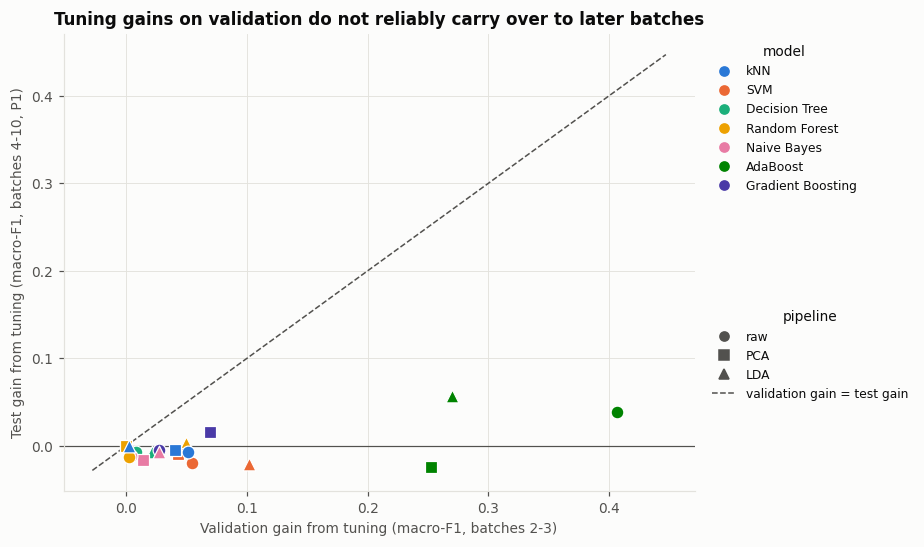

correlation between validation gain and test gain: 0.59 (without AdaBoost: -0.12); mean validation gain +0.069, mean test gain -0.002 (without AdaBoost -0.006)
configurations where tuning improved the test macro-F1: 3 improved, 11 worsened, 7 within +-0.005


In [4]:
dflt = base[(base.protocol == "P1") & base.model.isin(BASE)].groupby(["model", "variant"]).agg(default_f1=("macro_f1", "mean"), default_acc=("accuracy", "mean"))
tn = tuned[tuned.protocol == "P1"].groupby(["model", "variant"]).agg(tuned_f1=("macro_f1", "mean"), tuned_acc=("accuracy", "mean"))
cmp = dflt.join(tn).join(best.set_index(["model", "variant"])[["val_macro_f1_default", "val_macro_f1_tuned", "val_gain", "changed_from_default"]])
cmp["test_gain"] = cmp.tuned_f1 - cmp.default_f1; cmp["acc_gain"] = cmp.tuned_acc - cmp.default_acc
cmp = cmp.reset_index(); cmp.to_csv(RES / "07_tuning_vs_default_P1.csv", index=False)

fig, ax = plt.subplots(figsize=(7.4, 5.4))
col = {m: SERIES[i] for i, m in enumerate(BASE)}; mk = {"raw": "o", "PCA": "s", "LDA": "^"}
lim = max(cmp.val_gain.max(), cmp.test_gain.max()) * 1.1; lo = min(cmp.test_gain.min(), 0) * 1.15
ax.plot([lo, lim], [lo, lim], color=INK2, ls="--", lw=1, label="validation gain = test gain")
ax.axhline(0, color=INK2, lw=0.8)
for _, r in cmp.iterrows():
    ax.scatter(r.val_gain, r.test_gain, s=70, color=col[r.model], marker=mk[r.variant], edgecolor="white", linewidth=0.8, zorder=3)
ax.set_xlabel("Validation gain from tuning (macro-F1, batches 2-3)"); ax.set_ylabel("Test gain from tuning (macro-F1, batches 4-10, P1)")
ax.set_title("Tuning gains on validation do not reliably carry over to later batches")
h1 = [plt.Line2D([], [], marker="o", ls="", color=col[m], label=m) for m in BASE]; h2 = [plt.Line2D([], [], marker=mk[v], ls="", color=INK2, label=v) for v in VARS]
leg1 = ax.legend(handles=h1, title="model", frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.add_artist(leg1); ax.legend(handles=h2 + ax.get_legend_handles_labels()[0][:1], title="pipeline", frameon=False, fontsize=8, loc="upper left", bbox_to_anchor=(1.01, 0.42))
fig.savefig(FIG / "27_validation_vs_test_gain.png"); plt.show()
print(f"correlation between validation gain and test gain: {np.corrcoef(cmp.val_gain, cmp.test_gain)[0, 1]:.2f} "
      f"(without AdaBoost: {cmp[cmp.model != 'AdaBoost'][['val_gain', 'test_gain']].corr().iloc[0, 1]:.2f}); "
      f"mean validation gain {cmp.val_gain.mean():+.3f}, mean test gain {cmp.test_gain.mean():+.3f} "
      f"(without AdaBoost {cmp[cmp.model != 'AdaBoost'].test_gain.mean():+.3f})")
print(f"configurations where tuning improved the test macro-F1: {(cmp.test_gain > 0.005).sum()} improved, {(cmp.test_gain < -0.005).sum()} worsened, {(cmp.test_gain.abs() <= 0.005).sum()} within +-0.005")

## 4. Default vs tuned on the test batches (P1)

Mean macro-F1 over test batches 4-10. Left: defaults (notebook 04). Middle: tuned. Right: change (orange = tuning helped, blue = tuning hurt).

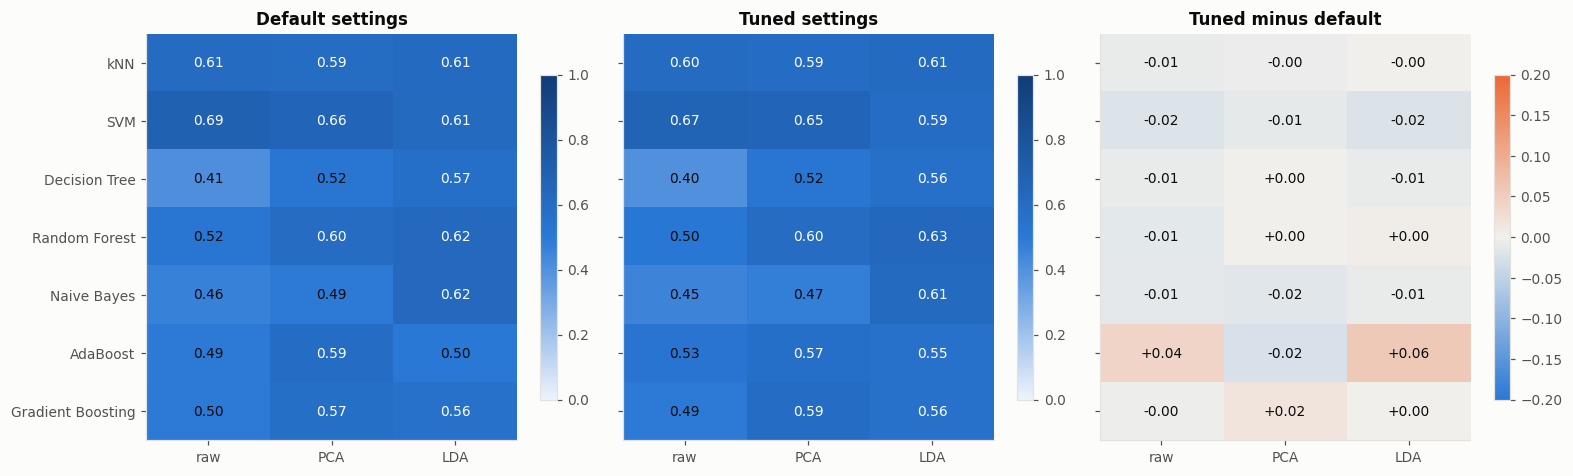

Eight best tuned configurations on P1 (descriptive):


,model,variant,default_f1,tuned_f1,test_gain,default_acc,tuned_acc
0,SVM,raw,0.690,0.670,-0.019,0.705,0.724
1,SVM,PCA,0.660,0.650,-0.010,0.666,0.654
2,Random Forest,LDA,0.625,0.628,0.003,0.647,0.640
3,Naive Bayes,LDA,0.621,0.614,-0.007,0.632,0.623
4,kNN,LDA,0.610,0.609,-0.001,0.640,0.637
5,kNN,raw,0.609,0.602,-0.007,0.615,0.602
6,Random Forest,PCA,0.599,0.599,0.000,0.646,0.646
7,SVM,LDA,0.614,0.594,-0.021,0.666,0.661


In [5]:
def piv(col): return cmp.pivot(index="model", columns="variant", values=col).loc[BASE, VARS]
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), sharey=True)
for ax, (title, t, cm, vmin, vmax) in zip(axes, [("Default settings", piv("default_f1"), SEQ, 0, 1), ("Tuned settings", piv("tuned_f1"), SEQ, 0, 1),
                                                   ("Tuned minus default", piv("test_gain"), DIV, -0.2, 0.2)]):
    im = ax.imshow(t.values, cmap=cm, vmin=vmin, vmax=vmax, aspect="auto"); ax.grid(False)
    ax.set_xticks(range(3)); ax.set_xticklabels(VARS); ax.set_yticks(range(len(BASE))); ax.set_yticklabels(BASE); ax.set_title(title)
    for i in range(t.shape[0]):
        for j in range(3):
            v = t.values[i, j]; txt = f"{v:+.2f}" if "minus" in title else f"{v:.2f}"
            dark = (v > 0.55) if "minus" not in title else (abs(v) > 0.14)
            ax.text(j, i, txt, ha="center", va="center", fontsize=9, color="white" if dark else INK)
    fig.colorbar(im, ax=ax, shrink=0.8)
fig.tight_layout(); fig.savefig(FIG / "28_tuned_vs_default_heatmap.png"); plt.show()

top = cmp.sort_values("tuned_f1", ascending=False).head(8)[["model", "variant", "default_f1", "tuned_f1", "test_gain", "default_acc", "tuned_acc"]]
print("Eight best tuned configurations on P1 (descriptive):"); display(top.round(3).reset_index(drop=True))

## 5. Per batch: tuned vs default for the strongest models

How do the best tuned configurations behave on each test batch compared with the best default model (SVM, scaling only)?

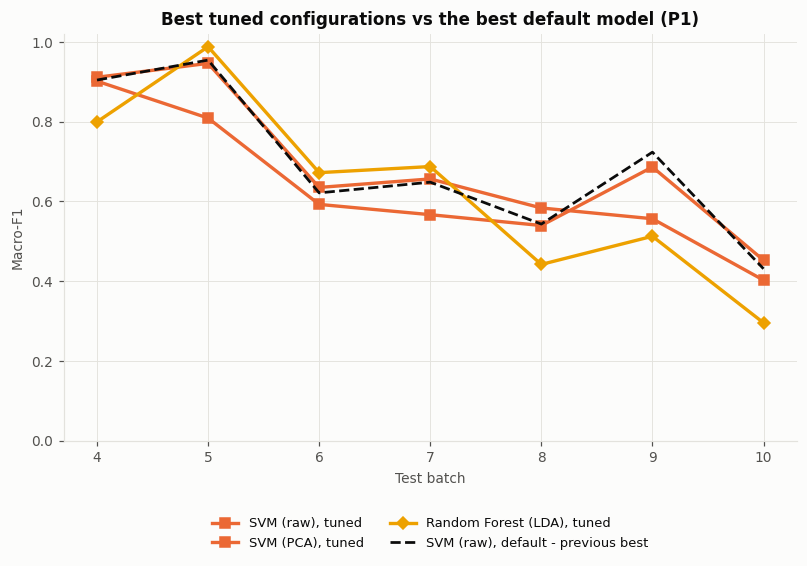

In [6]:
tp = tuned[tuned.protocol == "P1"]
best_cfgs = cmp.sort_values("tuned_f1", ascending=False).head(3)[["model", "variant"]].values.tolist()
fig, ax = plt.subplots(figsize=(8.6, 4.8)); col2 = {m: SERIES[i] for i, m in enumerate(BASE)}
for m, v in best_cfgs:
    d = tp[(tp.model == m) & (tp.variant == v)]; ax.plot(d.test_batch, d.macro_f1, color=col2[m], marker=MARKERS[BASE.index(m)], ms=6, lw=2.2, label=f"{m} ({v}), tuned")
d = base[(base.protocol == "P1") & (base.model == "SVM") & (base.variant == "raw")]
ax.plot(d.test_batch, d.macro_f1, color=INK, ls="--", lw=1.8, label="SVM (raw), default - previous best")
ax.set_xlabel("Test batch"); ax.set_ylabel("Macro-F1"); ax.set_ylim(0, 1.02); ax.set_xticks(range(4, 11)); ax.set_title("Best tuned configurations vs the best default model (P1)")
ax.legend(frameon=False, fontsize=8.5, loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=2)
fig.savefig(FIG / "29_tuned_per_batch.png"); plt.show()

## 6. Rolling protocol P3 (test batches 4-10 only)

Same tuned settings (chosen on batches 1-3), but the model is retrained on all older batches for every test batch. The default comparison uses the same
test batches (4-10) from notebook 04.

In [7]:
d3 = base[(base.protocol == "P3") & base.model.isin(BASE) & (base.test_batch >= 4)].groupby(["model", "variant"]).macro_f1.mean().rename("default_f1")
t3 = tuned[tuned.protocol == "P3"].groupby(["model", "variant"]).macro_f1.mean().rename("tuned_f1")
c3 = pd.concat([d3, t3], axis=1).reset_index(); c3["gain"] = c3.tuned_f1 - c3.default_f1; c3.to_csv(RES / "07_tuning_vs_default_P3_B4-10.csv", index=False)
print("P3 (test batches 4-10): mean macro-F1, default vs tuned"); display(c3.pivot(index="model", columns="variant", values=["default_f1", "tuned_f1", "gain"]).loc[BASE].round(3))
print(f"P3: {(c3.gain > 0.005).sum()} improved, {(c3.gain < -0.005).sum()} worsened, {(c3.gain.abs() <= 0.005).sum()} within +-0.005 (of {len(c3)})")

P3 (test batches 4-10): mean macro-F1, default vs tuned


default_f1               tuned_f1                 gain  \
variant                  LDA    PCA    raw      LDA    PCA    raw    LDA   
model                                                                      
kNN                    0.838  0.736  0.779    0.841  0.726  0.770  0.003   
SVM                    0.836  0.746  0.809    0.830  0.752  0.814 -0.005   
Decision Tree          0.809  0.617  0.631    0.814  0.617  0.644  0.005   
Random Forest          0.836  0.759  0.764    0.839  0.759  0.744  0.003   
Naive Bayes            0.853  0.503  0.455    0.843  0.505  0.452 -0.010   
AdaBoost               0.670  0.623  0.549    0.815  0.718  0.693  0.145   
Gradient Boosting      0.819  0.721  0.695    0.819  0.723  0.709  0.000   

                                 
variant              PCA    raw  
model                            
kNN               -0.011 -0.009  
SVM                0.006  0.005  
Decision Tree      0.000  0.013  
Random Forest      0.000 -0.019  
Naive Bayes        0.002 -0.003  
AdaBoost           0.095  0.144  
Gradient Boosting  0.002  0.014

P3: 6 improved, 5 worsened, 10 within +-0.005 (of 21)


## 7. Key takeaways

Settings were chosen on batches 1-3 only (forward-chaining validation: train B1 / validate B2, train B1+B2 / validate B3) and tested on the untouched batches 4-10.

| P1 (train B1-3) | Accuracy | Macro-F1 |
|---|---|---|
| SVM, scaling only, **default** (previous best) | 70.5% | **69.0%** |
| SVM, scaling only, **tuned** (C=100, gamma=0.01) | **72.4%** | 67.0% |
| SVM, PCA, tuned | 65.4% | 65.0% |
| Random Forest, LDA, tuned | 64.0% | 62.8% |
| Naive Bayes, LDA, tuned | 62.3% | 61.4% |
| kNN, LDA, tuned | 63.7% | 60.9% |

1. **Tuning did not improve the headline result.** Tuning changed the setting in 18 of 21 model/pipeline combinations and raised the validation macro-F1 by +0.069 on average (up to +0.407). On the untouched test batches the mean change is **-0.002**: 3 combinations improved by more than 0.005, **11 got worse**, 7 stayed within +-0.005. The best default model (SVM, scaling only, 69.0% macro-F1) remains the best by macro-F1; its tuned version has the highest accuracy so far (72.4% vs 70.5%) but lower macro-F1 (67.0% vs 69.0%).
2. **Validation gains do not predict test gains.** The correlation is 0.59, but it comes entirely from AdaBoost; without it the correlation is -0.12 and the mean test gain is -0.006. AdaBoost is the exception because its default (50 rounds of one-split stumps) is very weak (validation macro-F1 0.39 on raw features); depth-3 trees with 200 rounds reach 0.80 on validation and gain +0.039 (raw) and +0.057 (LDA) on test, but lose 0.024 with PCA.
3. **Tuning chose more flexible, more local settings, and those did not help later batches.** SVM moved to C=100 with a larger gamma, and kNN to k=1 (raw and PCA). Plausible reasons, which we have not proven: (a) the validation folds look only one batch ahead while the test batches are up to seven batches ahead; (b) validation batches 2-3 contain almost no Toluene (5 and 0 samples), so the biggest weakness found in notebook 06 is invisible to the tuning; (c) only two small folds, so some selections are noisy. A check by distance shows only small, mixed effects (mean test gain +0.005 on batches 4-5, +0.003 on 6-7, -0.011 on 8-10), so we do **not** claim a clean near/far pattern.
4. **Rolling retraining (P3, test batches 4-10).** Among 21 combinations, 6 improved, 5 got worse and 10 stayed within +-0.005; the mean gain of +0.018 is driven by AdaBoost with LDA (67.0% to 81.5%). The leaders barely change: Naive Bayes with LDA 85.3% (default) vs 84.3% (tuned), kNN with LDA 83.8% vs 84.1%, Random Forest with LDA 83.6% vs 83.9%. The tuned Random Forest with LDA has the best P3 accuracy (86.1%).
5. **What this means for the project.** With a drifting target, hyperparameter tuning on earlier batches is not a route to drift robustness: the defaults were already close to the best achievable here, and the settings that look best on near-term validation do not transfer. This points to the **drift-mitigation methods** (sliding-window retraining, per-batch standardisation, recency weighting) as the more promising next step, together with a Toluene-aware validation scheme.
6. **Caveats.** Differences of about +-0.02 are within the noise of the small test batches (significance tests come later). Tuning used grids of 8-32 settings per model; larger searches could behave differently, but tuned gains that vanish on the test batches are a warning about over-fitting to the validation period rather than about the grid size.